# BankNifty Exploratory Data Analysis (EDA)

This notebook provides step-by-step exploratory analysis of BankNifty historical data for the stock prediction system.

## Table of Contents
1. [Setup and Imports](#1-setup-and-imports)
2. [Load Data](#2-load-data)
3. [Data Overview](#3-data-overview)
4. [Missing Values Analysis](#4-missing-values-analysis)
5. [OHLCV Distribution Analysis](#5-ohlcv-distribution-analysis)
6. [Time Series Visualization](#6-time-series-visualization)
7. [Returns Analysis](#7-returns-analysis)
8. [Correlation Analysis](#8-correlation-analysis)
9. [Target Variable Analysis](#9-target-variable-analysis)
10. [Summary and Insights](#10-summary-and-insights)

## 1. Setup and Imports

In [1]:
# Standard library imports
import os
import sys
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

print("Setup complete!")

Setup complete!


## 2. Load Data

Load the processed BankNifty data. If processed data doesn't exist, we'll demonstrate how to generate it.

In [2]:
# Define data paths
DATA_DIR = Path('../data/processed/')
TRAIN_PATH = DATA_DIR / 'train.csv'
VAL_PATH = DATA_DIR / 'val.csv'
TEST_PATH = DATA_DIR / 'test.csv'

# Check if processed data exists
if TRAIN_PATH.exists():
    print("Loading processed data...")
    train_df = pd.read_csv(TRAIN_PATH, index_col=0, parse_dates=True)
    val_df = pd.read_csv(VAL_PATH, index_col=0, parse_dates=True)
    test_df = pd.read_csv(TEST_PATH, index_col=0, parse_dates=True)
    
    # Combine for EDA
    df = pd.concat([train_df, val_df, test_df])
    print(f"Loaded {len(df):,} total records")
else:
    print("Processed data not found. Creating sample data for demonstration...")
    # Create sample data for demonstration
    np.random.seed(42)
    n_samples = 2000
    
    dates = pd.date_range(start='2024-01-01', periods=n_samples, freq='15min')
    base_price = 45000
    
    # Generate realistic OHLCV data
    close = base_price + np.cumsum(np.random.randn(n_samples) * 50)
    high = close + np.abs(np.random.randn(n_samples) * 30)
    low = close - np.abs(np.random.randn(n_samples) * 30)
    open_price = close + np.random.randn(n_samples) * 20
    volume = np.random.randint(10000, 100000, n_samples)
    
    df = pd.DataFrame({
        'open': open_price,
        'high': high,
        'low': low,
        'close': close,
        'volume': volume
    }, index=dates)
    
    # Create target
    df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
    df = df.iloc[:-1]  # Remove last row with NaN target
    
    print(f"Created sample data with {len(df):,} records")

Loading processed data...
Loaded 18,095 total records
Loaded 18,095 total records


## 3. Data Overview

Basic exploration of the dataset structure, shape, and types.

In [3]:
# Display basic info
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"Date Range: {df.index.min()} to {df.index.max()}")
print(f"Time Span: {(df.index.max() - df.index.min()).days} days")
print(f"\nColumns: {list(df.columns)}")

DATASET OVERVIEW

Shape: (18095, 6)
Date Range: 2022-12-21 14:45:00+05:30 to 2025-11-27 15:00:00+05:30
Time Span: 1072 days

Columns: ['open', 'high', 'low', 'close', 'volume', 'target']


In [4]:
# Display data types
print("\nData Types:")
print(df.dtypes)


Data Types:
open      float64
high      float64
low       float64
close     float64
volume    float64
target      int64
dtype: object


In [5]:
# Display first few rows
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,open,high,low,close,volume,target
datetime,,,,,,
2022-12-21 14:45:00+05:30,42872.00,42912.70,42624.70,42680.05,NaN,0
2022-12-21 15:00:00+05:30,42674.80,42754.35,42551.75,42610.15,NaN,1
2022-12-21 15:15:00+05:30,42609.15,42669.45,42568.15,42658.05,NaN,0
2022-12-22 09:15:00+05:30,42864.00,42922.40,42553.70,42568.75,NaN,0
2022-12-22 09:30:00+05:30,42567.80,42615.30,42449.85,42511.45,NaN,1


In [6]:
# Display last few rows
print("\nLast 5 Rows:")
df.tail()


Last 5 Rows:


,open,high,low,close,volume,target
datetime,,,,,,
2025-11-27 14:00:00+05:30,59670.80,59698.45,59621.65,59665.40,NaN,1
2025-11-27 14:15:00+05:30,59668.80,59764.00,59616.85,59741.25,NaN,0
2025-11-27 14:30:00+05:30,59745.20,59766.90,59679.20,59735.00,NaN,0
2025-11-27 14:45:00+05:30,59729.25,59733.15,59635.95,59664.95,NaN,1
2025-11-27 15:00:00+05:30,59662.95,59768.15,59662.95,59722.35,NaN,1


In [7]:
# Statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,open,high,low,close,volume,target
count,18095.000000,18095.000000,18095.000000,18095.000000,0.0,18095.000000
mean,48950.759367,49002.245369,48897.669889,48950.470525,NaN,0.505554
std,5034.669761,5036.245371,5034.331262,5035.348446,NaN,0.499983
min,38668.150000,38740.900000,38617.800000,38666.300000,NaN,0.000000
25%,44479.700000,44517.800000,44442.450000,44479.025000,NaN,0.000000
50%,48653.600000,48710.250000,48602.950000,48651.950000,NaN,1.000000
75%,52562.425000,52624.725000,52523.950000,52563.675000,NaN,1.000000
max,59852.600000,59866.600000,59800.150000,59850.100000,NaN,1.000000


## 4. Missing Values Analysis

Check for and visualize missing values in the dataset.

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print("Missing Values Analysis:")
print(missing_df)

Missing Values Analysis:
        Missing Count  Missing Percentage
open                0                 0.0
high                0                 0.0
low                 0                 0.0
close               0                 0.0
volume          18095               100.0
target              0                 0.0


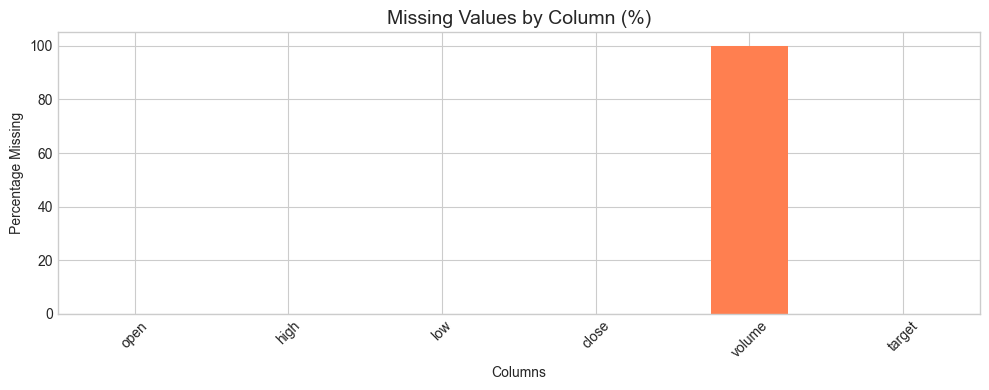

In [9]:
# Visualize missing values if any exist
if missing.sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_pct.plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Missing Values by Column (%)', fontsize=14)
    ax.set_xlabel('Columns')
    ax.set_ylabel('Percentage Missing')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in the dataset!")

## 5. OHLCV Distribution Analysis

Analyze the distribution of Open, High, Low, Close prices and Volume.

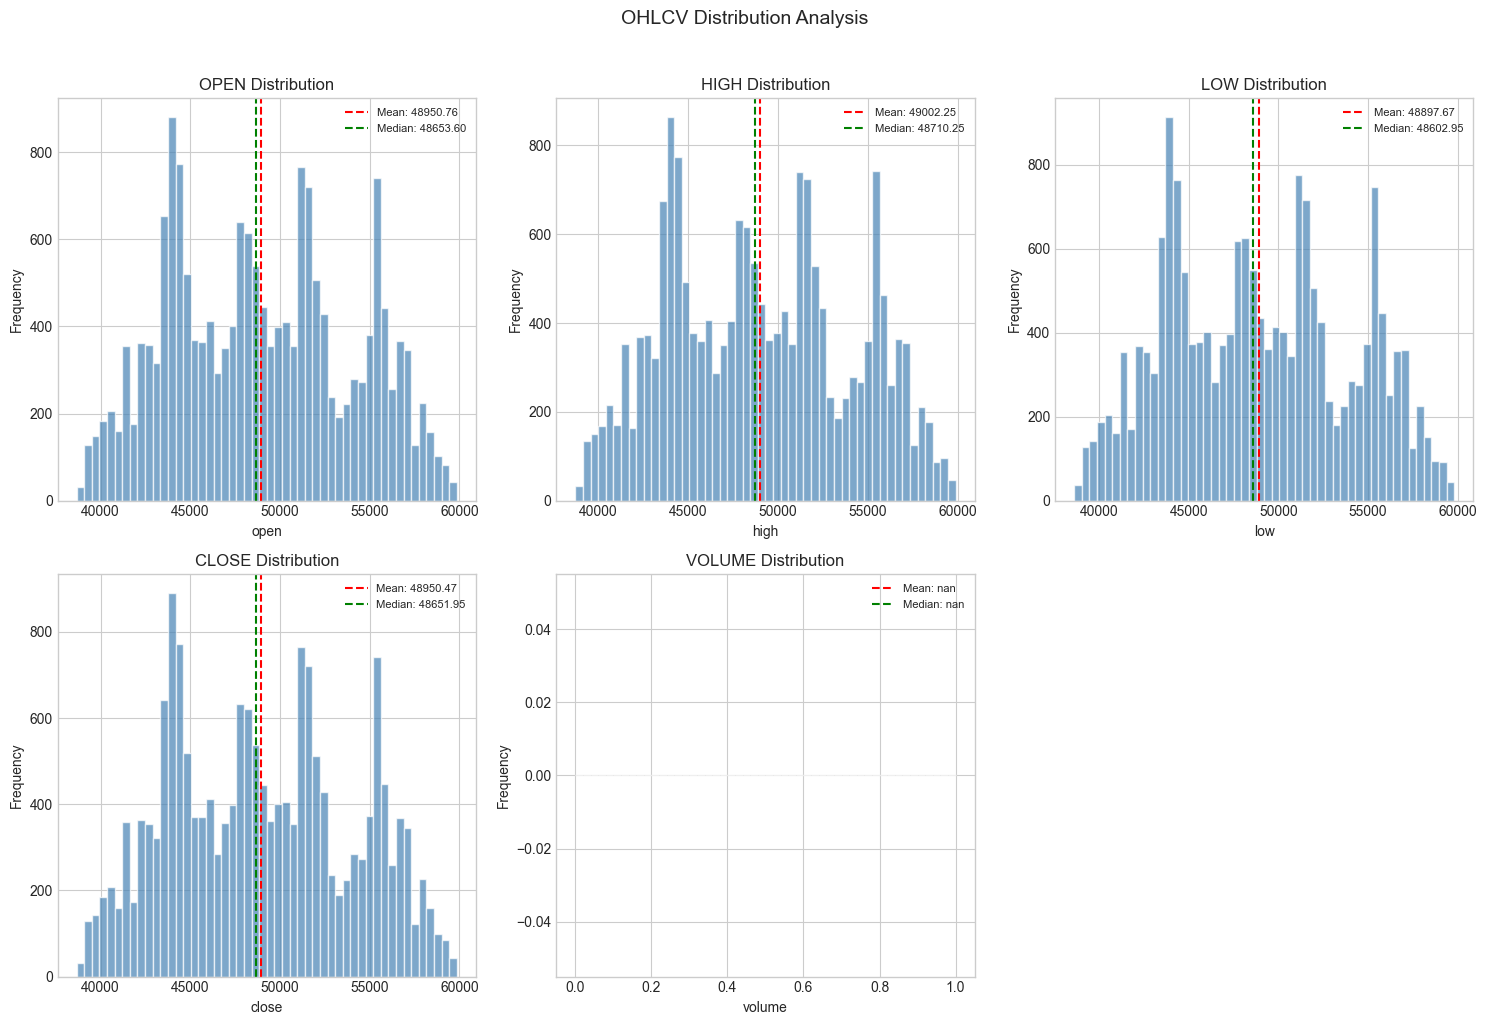

In [10]:
# OHLCV columns
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']

# Plot histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(ohlcv_cols):
    ax = axes[i]
    df[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title(f'{col.upper()} Distribution', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    
    # Add mean and median lines
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    ax.legend(fontsize=8)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('OHLCV Distribution Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

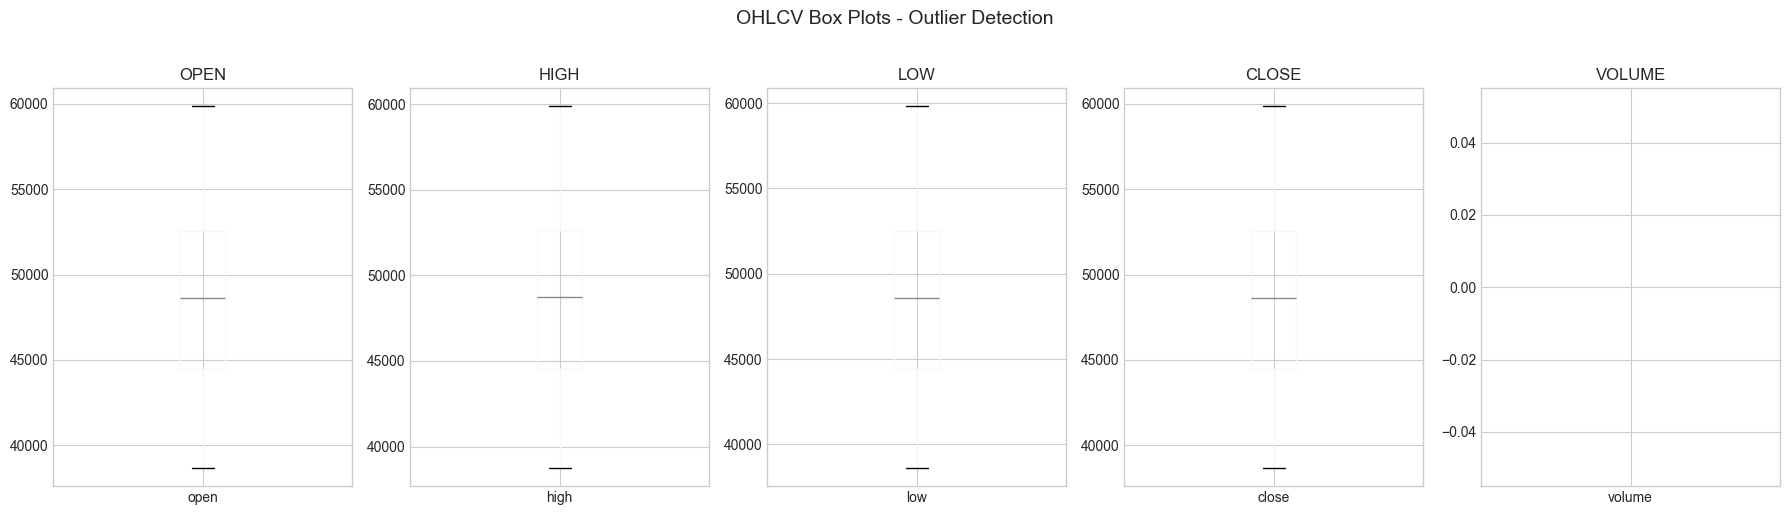

In [11]:
# Box plots for outlier detection
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(ohlcv_cols):
    ax = axes[i]
    df.boxplot(column=col, ax=ax)
    ax.set_title(f'{col.upper()}', fontsize=12)

plt.suptitle('OHLCV Box Plots - Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Time Series Visualization

Visualize price and volume over time.

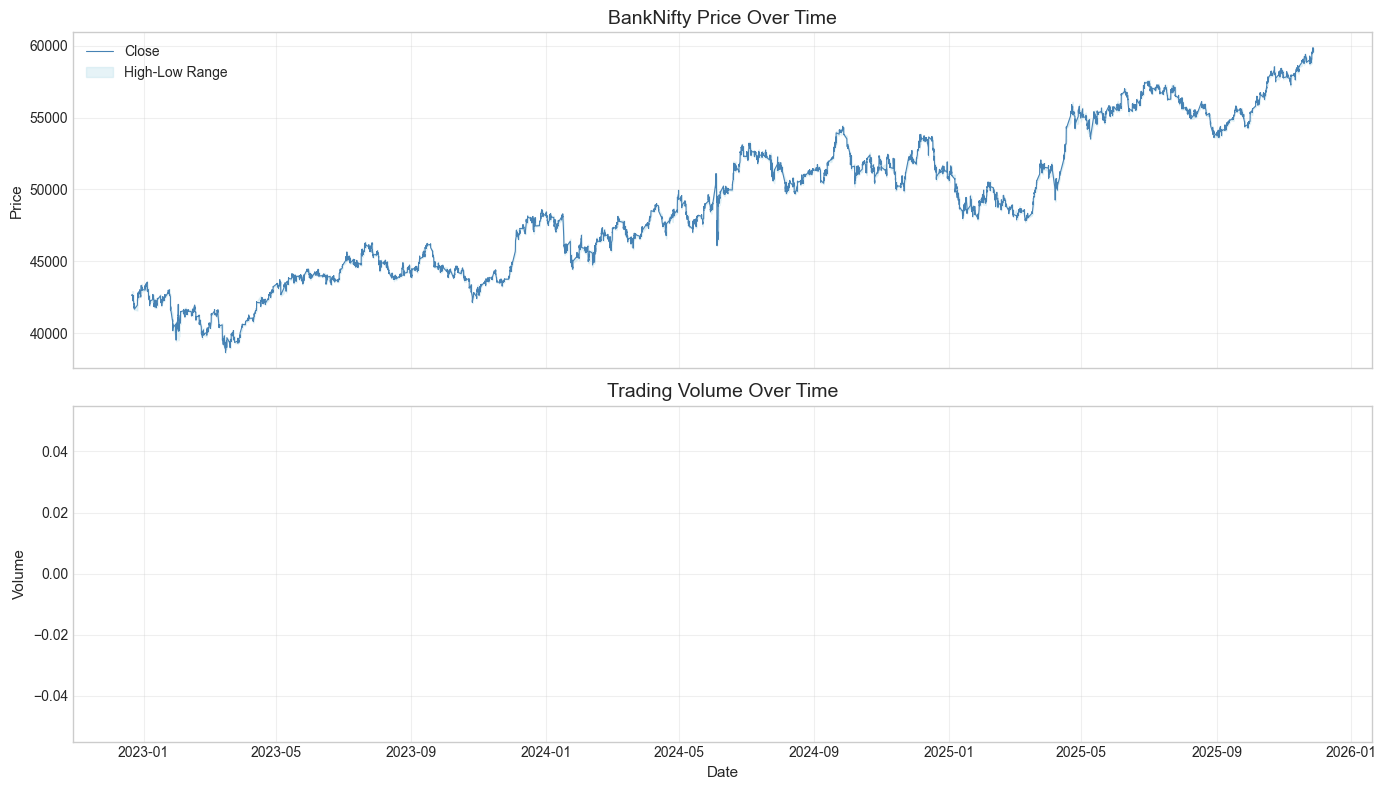

In [12]:
# Plot closing price over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price plot
ax1 = axes[0]
ax1.plot(df.index, df['close'], color='steelblue', linewidth=0.8, label='Close')
ax1.fill_between(df.index, df['low'], df['high'], alpha=0.3, color='lightblue', label='High-Low Range')
ax1.set_ylabel('Price', fontsize=11)
ax1.set_title('BankNifty Price Over Time', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Volume plot
ax2 = axes[1]
ax2.bar(df.index, df['volume'], color='coral', alpha=0.7, width=0.01)
ax2.set_ylabel('Volume', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_title('Trading Volume Over Time', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

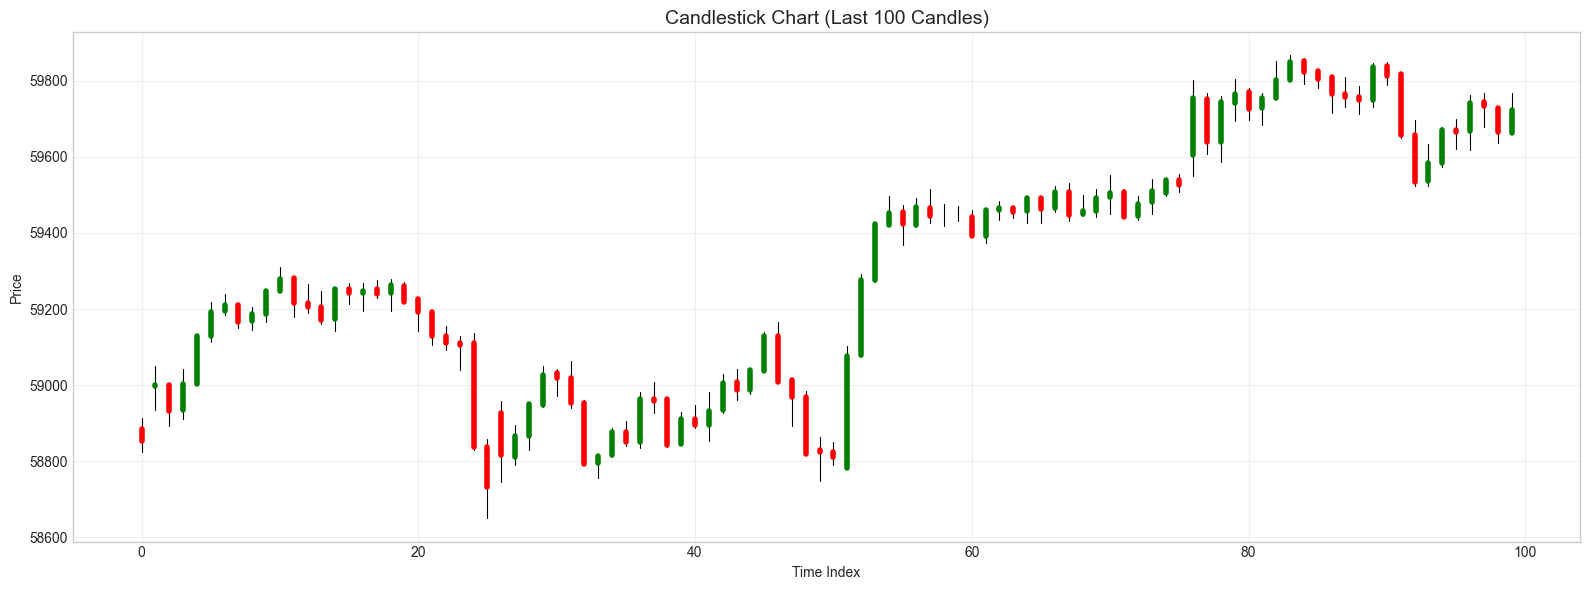

In [13]:
# Candlestick-style visualization (simplified)
# Show last 100 candles for clarity
sample_df = df.tail(100).copy()

fig, ax = plt.subplots(figsize=(16, 6))

# Create candlestick colors
colors = ['green' if close > open_ else 'red' 
          for open_, close in zip(sample_df['open'], sample_df['close'])]

# Plot high-low lines
for i, (idx, row) in enumerate(sample_df.iterrows()):
    ax.plot([i, i], [row['low'], row['high']], color='black', linewidth=0.8)
    ax.plot([i, i], [row['open'], row['close']], color=colors[i], linewidth=4)

ax.set_title('Candlestick Chart (Last 100 Candles)', fontsize=14)
ax.set_xlabel('Time Index')
ax.set_ylabel('Price')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Returns Analysis

Analyze price returns and their distribution.

In [14]:
# Calculate returns
df['returns'] = df['close'].pct_change() * 100  # Percentage returns
df['log_returns'] = np.log(df['close'] / df['close'].shift(1)) * 100

# Display returns statistics
print("Returns Statistics:")
print(f"Mean Return: {df['returns'].mean():.4f}%")
print(f"Std Dev: {df['returns'].std():.4f}%")
print(f"Min Return: {df['returns'].min():.4f}%")
print(f"Max Return: {df['returns'].max():.4f}%")
print(f"Skewness: {df['returns'].skew():.4f}")
print(f"Kurtosis: {df['returns'].kurtosis():.4f}")

Returns Statistics:
Mean Return: 0.0020%
Std Dev: 0.1784%
Min Return: -3.7662%
Max Return: 2.9397%
Skewness: -0.1404
Kurtosis: 36.8139


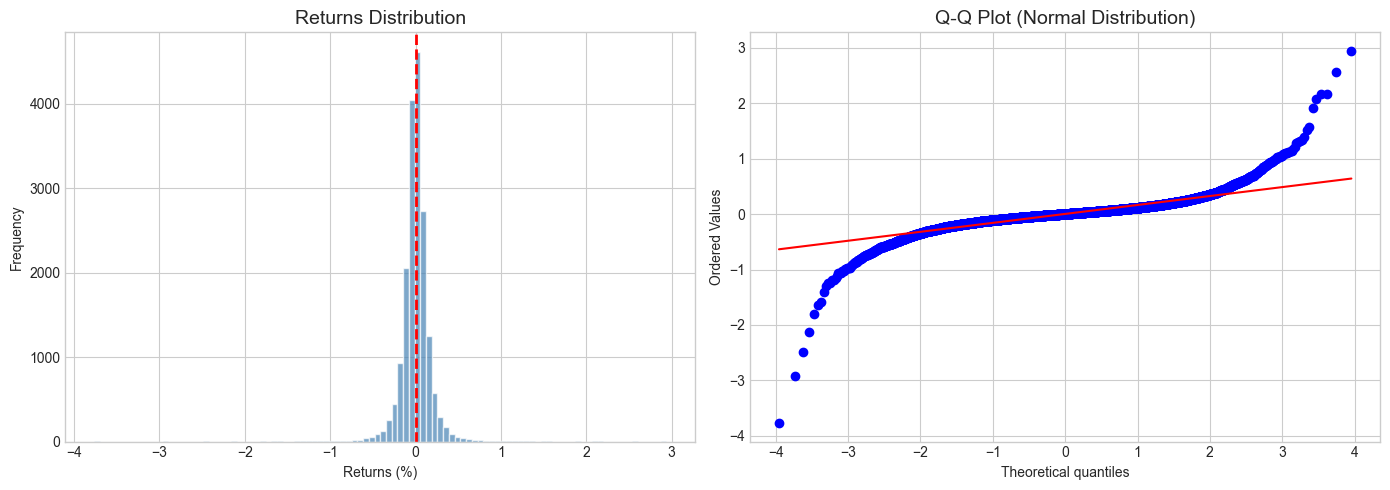

In [16]:
# Plot returns distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
df['returns'].dropna().hist(bins=100, ax=ax1, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.set_title('Returns Distribution', fontsize=14)
ax1.set_xlabel('Returns (%)')
ax1.set_ylabel('Frequency')

# Q-Q plot
from scipy import stats
ax2 = axes[1]
stats.probplot(df['returns'].dropna(), dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normal Distribution)', fontsize=14)

plt.tight_layout()
plt.show()

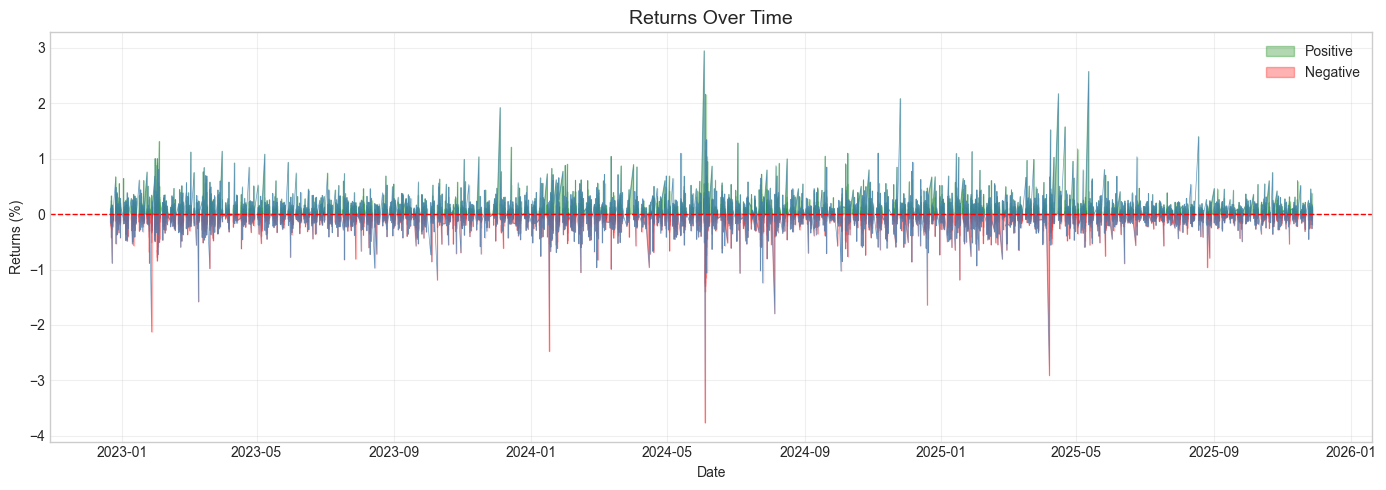

In [17]:
# Returns over time
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['returns'], color='steelblue', linewidth=0.5, alpha=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.fill_between(df.index, df['returns'], 0, where=df['returns'] > 0, 
                color='green', alpha=0.3, label='Positive')
ax.fill_between(df.index, df['returns'], 0, where=df['returns'] < 0, 
                color='red', alpha=0.3, label='Negative')
ax.set_title('Returns Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Returns (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Analyze correlations between features.

In [18]:
# Calculate correlation matrix
corr_cols = ['open', 'high', 'low', 'close', 'volume', 'returns']
available_cols = [col for col in corr_cols if col in df.columns]
corr_matrix = df[available_cols].corr()

# Display correlation matrix
print("Correlation Matrix:")
print(corr_matrix.round(4))

Correlation Matrix:
           open    high     low   close  volume  returns
open     1.0000  0.9999  0.9999  0.9999     NaN  -0.0003
high     0.9999  1.0000  0.9999  0.9999     NaN   0.0056
low      0.9999  0.9999  1.0000  0.9999     NaN   0.0062
close    0.9999  0.9999  0.9999  1.0000     NaN   0.0121
volume      NaN     NaN     NaN     NaN     NaN      NaN
returns -0.0003  0.0056  0.0062  0.0121     NaN   1.0000


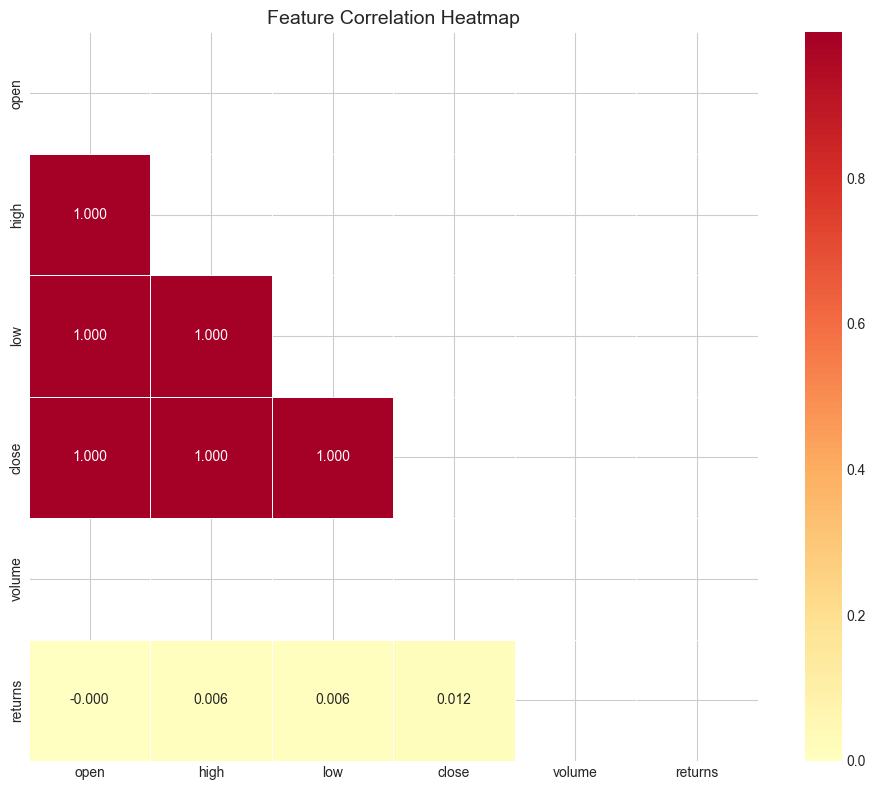

In [19]:
# Visualize correlation matrix as heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, fmt='.3f', ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Pairplot for visual correlation (subset)
subset_cols = ['open', 'close', 'volume', 'returns']
available_subset = [col for col in subset_cols if col in df.columns]

# Use sample for faster plotting
sample = df[available_subset].dropna().sample(min(1000, len(df)))
sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pairwise Feature Relationships', y=1.02, fontsize=14)
plt.show()

ValueError: a must be greater than 0 unless no samples are taken

## 9. Target Variable Analysis

Analyze the target variable (directional movement) distribution and patterns.

In [21]:
# Target distribution
if 'target' in df.columns:
    target_counts = df['target'].value_counts()
    target_pct = df['target'].value_counts(normalize=True) * 100
    
    print("Target Variable Distribution:")
    print(f"DOWN (0): {target_counts.get(0, 0):,} ({target_pct.get(0, 0):.2f}%)")
    print(f"UP (1): {target_counts.get(1, 0):,} ({target_pct.get(1, 0):.2f}%)")
    print(f"\nClass Balance Ratio: {target_counts.get(0, 1) / target_counts.get(1, 1):.4f}")
else:
    print("Target column not found in data.")

Target Variable Distribution:
DOWN (0): 8,947 (49.44%)
UP (1): 9,148 (50.56%)

Class Balance Ratio: 0.9780


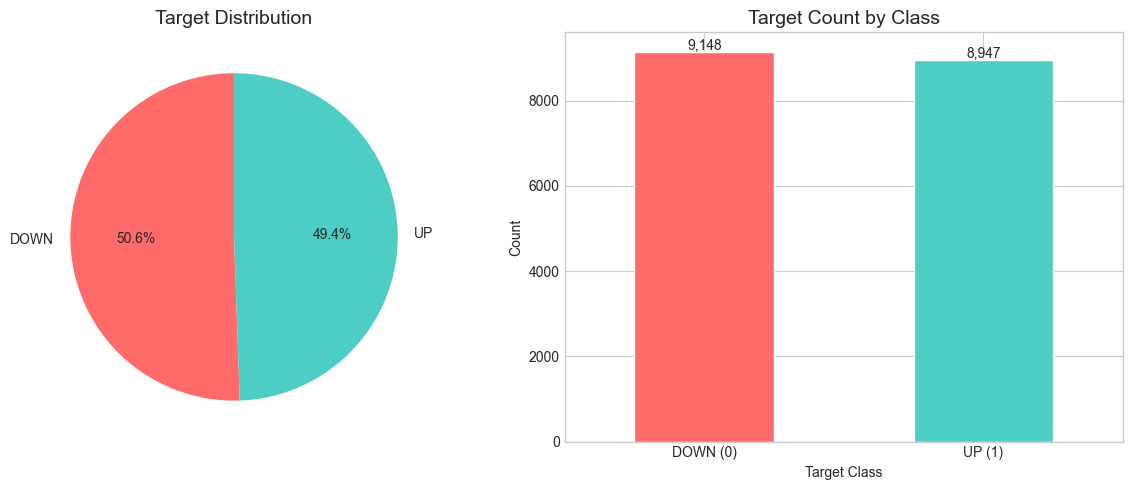

In [22]:
# Visualize target distribution
if 'target' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Pie chart
    ax1 = axes[0]
    colors = ['#ff6b6b', '#4ecdc4']
    target_counts.plot(kind='pie', ax=ax1, autopct='%1.1f%%', colors=colors,
                      labels=['DOWN', 'UP'], startangle=90)
    ax1.set_ylabel('')
    ax1.set_title('Target Distribution', fontsize=14)
    
    # Bar chart
    ax2 = axes[1]
    target_counts.plot(kind='bar', ax=ax2, color=colors, edgecolor='white')
    ax2.set_xticklabels(['DOWN (0)', 'UP (1)'], rotation=0)
    ax2.set_title('Target Count by Class', fontsize=14)
    ax2.set_xlabel('Target Class')
    ax2.set_ylabel('Count')
    
    for i, (count, pct) in enumerate(zip(target_counts, target_pct)):
        ax2.text(i, count + 50, f'{count:,}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

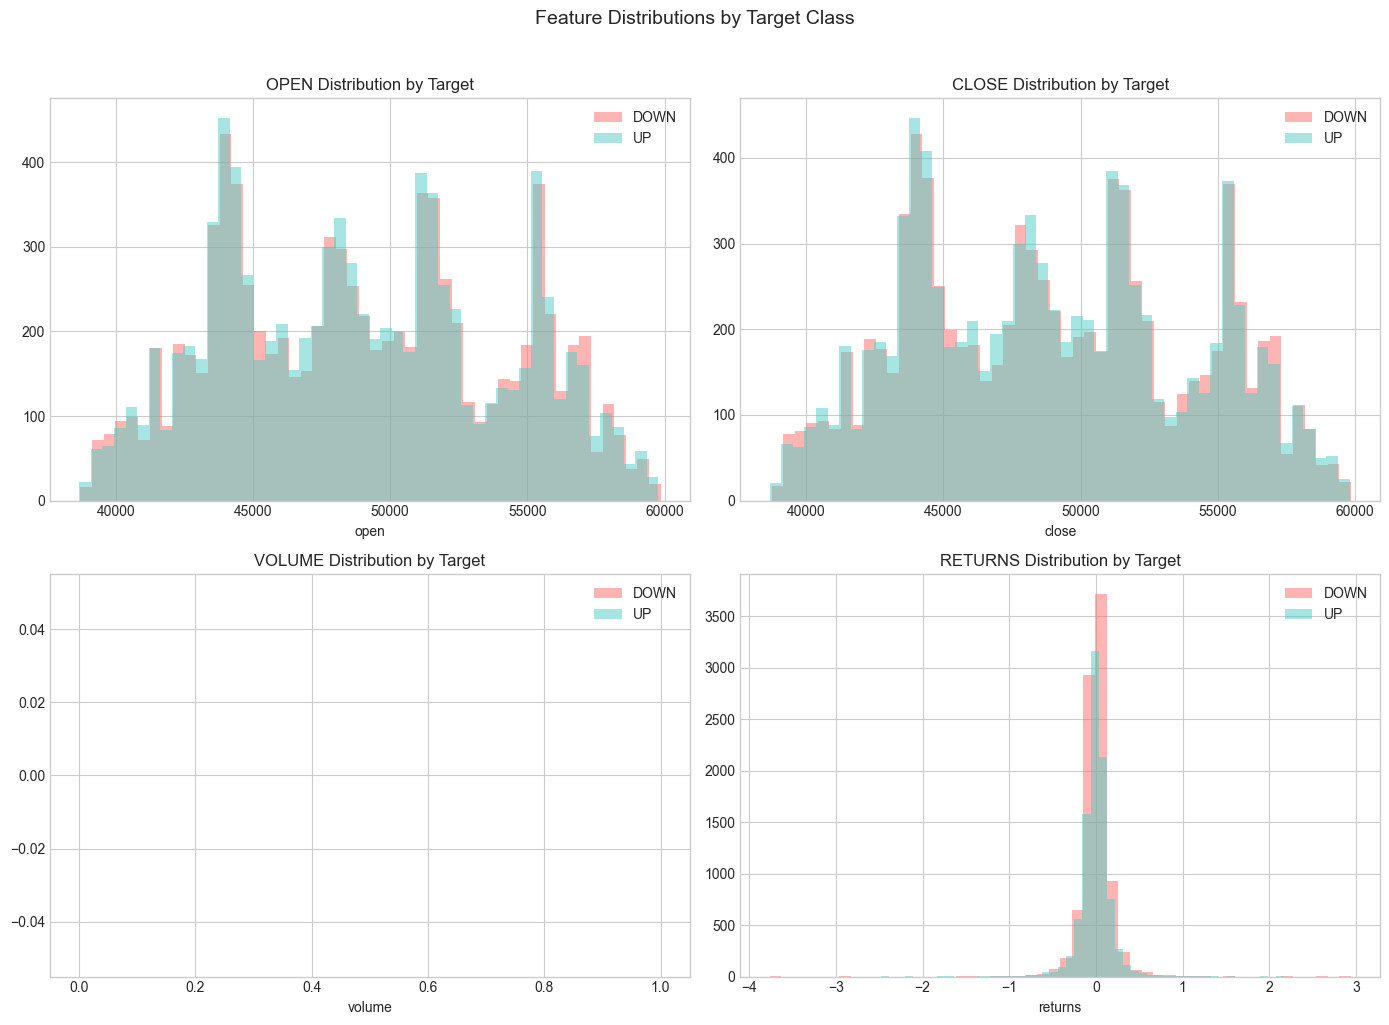

In [23]:
# Feature distributions by target class
if 'target' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    features_to_plot = ['open', 'close', 'volume', 'returns']
    available_features = [f for f in features_to_plot if f in df.columns]
    
    for i, col in enumerate(available_features):
        ax = axes[i]
        for target, color, label in [(0, '#ff6b6b', 'DOWN'), (1, '#4ecdc4', 'UP')]:
            df[df['target'] == target][col].hist(bins=50, ax=ax, alpha=0.5, 
                                                  color=color, label=label)
        ax.set_title(f'{col.upper()} Distribution by Target', fontsize=12)
        ax.set_xlabel(col)
        ax.legend()
    
    plt.suptitle('Feature Distributions by Target Class', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 10. Summary and Insights

Key findings from the exploratory data analysis.

In [24]:
# Generate summary
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print(f"\n1. DATA OVERVIEW")
print(f"   - Total Records: {len(df):,}")
print(f"   - Date Range: {df.index.min()} to {df.index.max()}")
print(f"   - Features: {list(df.columns)}")

print(f"\n2. DATA QUALITY")
print(f"   - Missing Values: {df.isnull().sum().sum()}")
print(f"   - Duplicate Indices: {df.index.duplicated().sum()}")

print(f"\n3. PRICE STATISTICS")
print(f"   - Mean Close: {df['close'].mean():.2f}")
print(f"   - Price Range: {df['close'].min():.2f} - {df['close'].max():.2f}")
print(f"   - Volatility (Std): {df['close'].std():.2f}")

if 'returns' in df.columns:
    print(f"\n4. RETURNS ANALYSIS")
    print(f"   - Mean Return: {df['returns'].mean():.4f}%")
    print(f"   - Return Std Dev: {df['returns'].std():.4f}%")
    print(f"   - Skewness: {df['returns'].skew():.4f}")
    print(f"   - Kurtosis: {df['returns'].kurtosis():.4f}")

if 'target' in df.columns:
    print(f"\n5. TARGET DISTRIBUTION")
    target_pct = df['target'].value_counts(normalize=True) * 100
    print(f"   - DOWN (0): {target_pct.get(0, 0):.2f}%")
    print(f"   - UP (1): {target_pct.get(1, 0):.2f}%")
    imbalance = abs(target_pct.get(0, 50) - 50)
    if imbalance > 5:
        print(f"   - Note: Dataset is {'imbalanced' if imbalance > 10 else 'slightly imbalanced'}")
    else:
        print(f"   - Note: Dataset is well-balanced")

print("\n" + "=" * 60)
print("EDA COMPLETE")
print("=" * 60)

EDA SUMMARY

1. DATA OVERVIEW
   - Total Records: 18,095
   - Date Range: 2022-12-21 14:45:00+05:30 to 2025-11-27 15:00:00+05:30
   - Features: ['open', 'high', 'low', 'close', 'volume', 'target', 'returns', 'log_returns']

2. DATA QUALITY
   - Missing Values: 18097
   - Duplicate Indices: 0

3. PRICE STATISTICS
   - Mean Close: 48950.47
   - Price Range: 38666.30 - 59850.10
   - Volatility (Std): 5035.35

4. RETURNS ANALYSIS
   - Mean Return: 0.0020%
   - Return Std Dev: 0.1784%
   - Skewness: -0.1404
   - Kurtosis: 36.8139

5. TARGET DISTRIBUTION
   - DOWN (0): 49.44%
   - UP (1): 50.56%
   - Note: Dataset is well-balanced

EDA COMPLETE


In [25]:
# Clean up temporary columns
if 'returns' in df.columns:
    df = df.drop(columns=['returns', 'log_returns'], errors='ignore')
print("Cleanup complete. EDA notebook finished!")

Cleanup complete. EDA notebook finished!
